In [24]:
import os
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad
from scipy.stats import norm

from bk_buster.generator.node_binary import (
    generate_data,
    make_graph,
    visualize_graph,
)
from bk_buster.utils.plot import set_plot_params, set_size

In [25]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Generation

In [26]:
num_nodes_per_class = 10
num_graphs = 100

# no overlap
# g1_dist_params = (0.3, 0.05)
# g2_dist_params = (0.7, 0.05)

# medium overlap
g1_dist_params = (0.45, 0.1)
g2_dist_params = (0.55, 0.1)

# calculate overlap ratio
def overlap(mu1, s1, mu2, s2):
    def p1(x):
        return norm.pdf(x, mu1, s1)
    def p2(x):
        return norm.pdf(x, mu2, s2)
    return quad(lambda x: np.minimum(p1(x), p2(x)), -np.inf, np.inf)[0]

overlap_ratio = overlap(g1_dist_params[0], g1_dist_params[1], g2_dist_params[0], g2_dist_params[1])
print(f"Overlap ratio: {overlap_ratio:.2f}")

X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42)

display(X.shape, y.shape)

Overlap ratio: 0.62


(100, 20)

(100, 20)

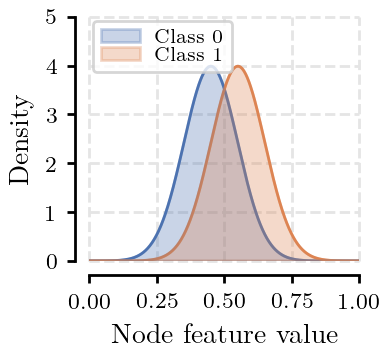

In [27]:
# draw distribution of node features

set_plot_params()
fig, ax = plt.subplots(figsize=set_size("ieee_1c", aspect_ratio=1.1, fraction=0.5))

# plot distribution curves
x = np.linspace(-0.5, 1.5, 1000)
g1_pdf = norm.pdf(x, g1_dist_params[0], g1_dist_params[1])
g2_pdf = norm.pdf(x, g2_dist_params[0], g2_dist_params[1])
plt.plot(x, g1_pdf, color=sns.color_palette("deep", n_colors=2)[0], zorder=5)
plt.plot(x, g2_pdf, color=sns.color_palette("deep", n_colors=2)[1], zorder=5)
plt.fill_between(x, g1_pdf, alpha=0.3, color=sns.color_palette("deep", n_colors=2)[0], label="Class 0", zorder=5)
plt.fill_between(x, g2_pdf, alpha=0.3, color=sns.color_palette("deep", n_colors=2)[1], label="Class 1", zorder=5)

ax.set_xlabel("Node feature value")
ax.set_xlim(0, 1)

ax.set_ylabel("Density")
ax.set_ylim(0, 5)

# legend
ax.legend(
    title=None,
    loc="upper left",
    labelspacing=0.05,
    borderaxespad=0.2,
)

ax.margins(0)

# despine
sns.despine(offset=5, trim=True)
for gl in ax.get_xgridlines() + ax.get_ygridlines():
    gl.set_clip_on(False)
    gl.set_in_layout(False)

fig_path = os.path.join(os.path.curdir, "syn_node_feat_dist.pdf")
fig.savefig(fig_path, bbox_inches="tight", pad_inches=0)

plt.show()

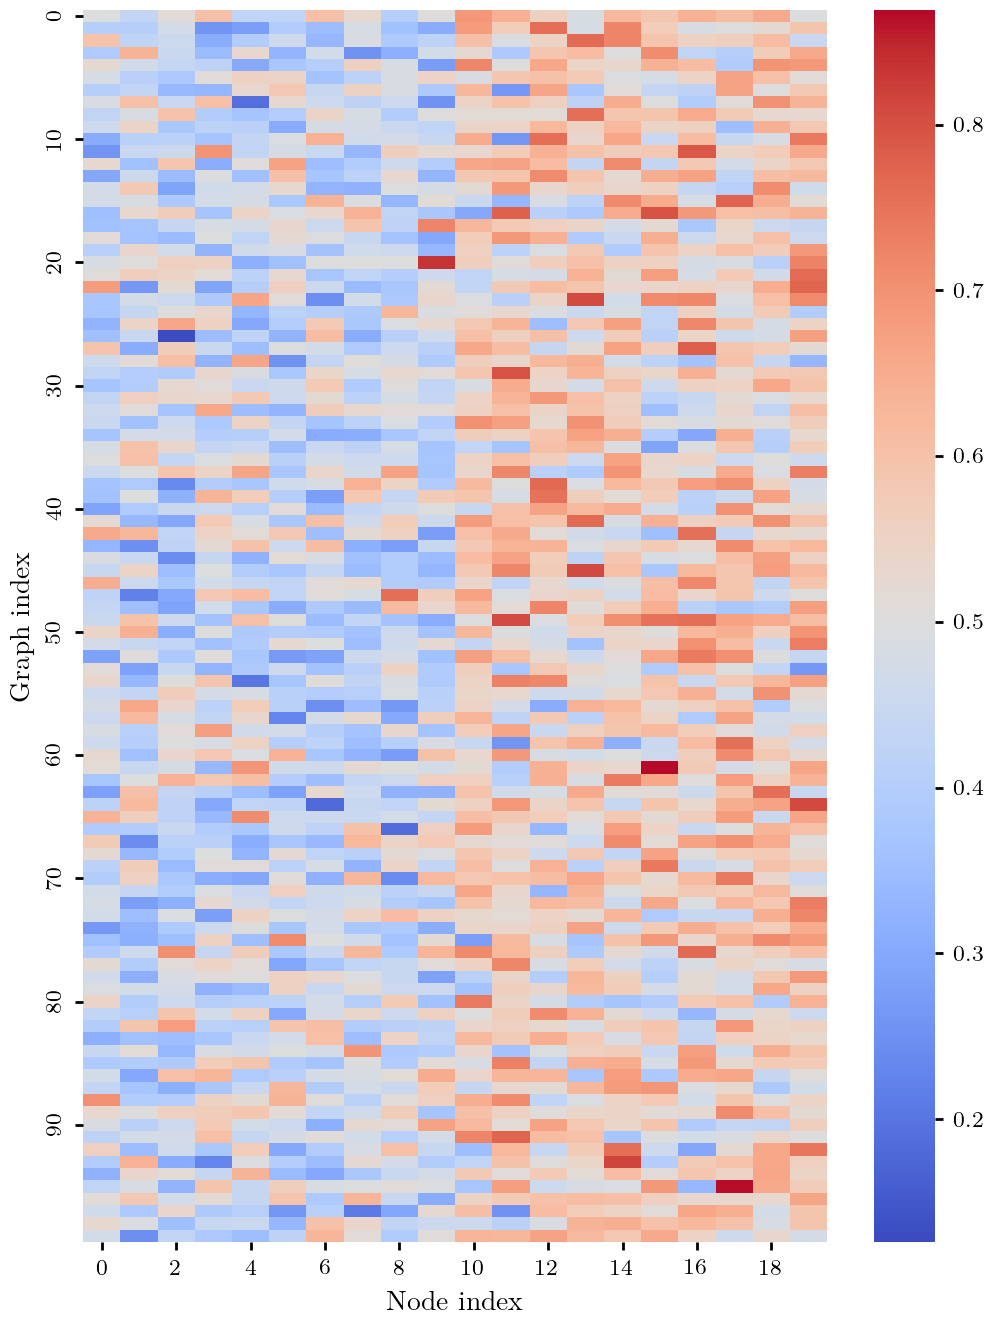

In [5]:
set_plot_params()
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(pd.DataFrame(X), cmap="coolwarm", center=0.5, yticklabels=10, xticklabels=2, ax=ax)

ax.set_xlabel("Node index")
ax.set_ylabel("Graph index")

ax.grid(False)

plt.show()

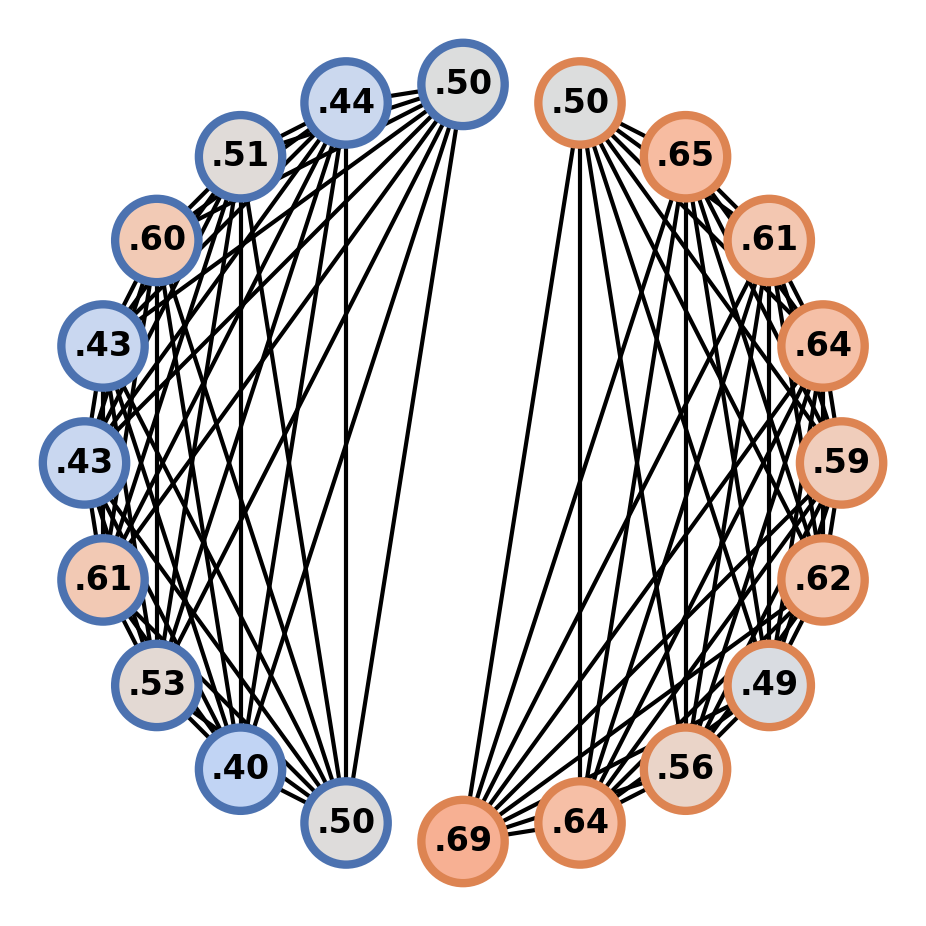

In [36]:
data_list = [make_graph(x, y) for x, y in zip(X, y)]

set_plot_params()
plt.rcParams["figure.dpi"] = 300
fig, ax = plt.subplots(1, 1, figsize=set_size("ieee_1c", aspect_ratio=1.0, fraction=0.5))

plt.rcParams["text.usetex"] = False
ax = visualize_graph(
    data=data_list[0],
    layout="circular",
    draw_node_labels=True,
    draw_borders=True,
    ax=ax,
    kwargs={
        "node_size": 80,
        "font_size": 4,
        "node_border_width": 1,
        "edge_color": "black",
        "edge_width": 0.5,
    }
)
ax.set_box_aspect(1)

ax.grid(False)
ax.set_axis_off()
ax.margins(0.02)
plt.tight_layout()

fig_path = os.path.join(os.path.curdir, "syn_node_graph.pdf")
fig.savefig(fig_path, bbox_inches="tight", pad_inches=0)

plt.show()

## Add Edges

In [79]:
num_edges = num_nodes_per_class * (num_nodes_per_class - 1)
num_non_edges = num_nodes_per_class * (2 * num_nodes_per_class - 1) - num_edges
print(f"Number of edges: {num_edges}, number of non-edges: {num_non_edges}")

# perturbation
non_edges = []
for i in range(10):
    for j in range(10, 20):
        if i != j:
            non_edges.append(["add", i, j])
            
num_extra_edges = 10
rng = np.random.default_rng(42)
edge_ops = rng.choice(non_edges, size=num_extra_edges, replace=False)

# make it worse
# edge_ops = edge_ops.tolist()
# i = range(10)
# i_even, i_odd = i[::2], i[1::2]
# for i, j in zip(i_even, i_odd):
#     edge_ops.append(["remove", i, j])
# j = range(10, 20)
# j_even, j_odd = j[::2], j[1::2]
# for j, k in zip(j_even, j_odd):
#     edge_ops.append(["remove", j, k])

data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

Number of edges: 90, number of non-edges: 100


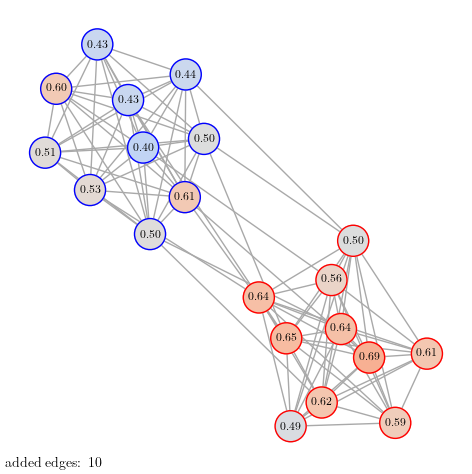

200


In [80]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax = visualize_graph(data=data_list[0], layout="spring", ax=ax)
ax.set_box_aspect(1)
ax.annotate(f"added edges: {num_extra_edges}", xy=(0, 0), xytext=(0, 0), textcoords="axes fraction")
plt.show()

print(data_list[0].num_edges)

## Remove Edges

In [52]:
# generate X and y
g1_dist_params = (0.4, 0.2)
g2_dist_params = (0.6, 0.2)
num_nodes_per_class = 10
num_graphs = 100
X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42)

# get the list of existing edges
existing_edges = list(combinations(range(0, num_nodes_per_class), 2)) + list(combinations(range(num_nodes_per_class, num_nodes_per_class*2), 2))

num_edges_to_remove = 90
rng = np.random.default_rng(42)
edges_to_remove = rng.choice(existing_edges, size=num_edges_to_remove, replace=False)
edge_ops = [["remove", src, dst] for src, dst in edges_to_remove]
data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

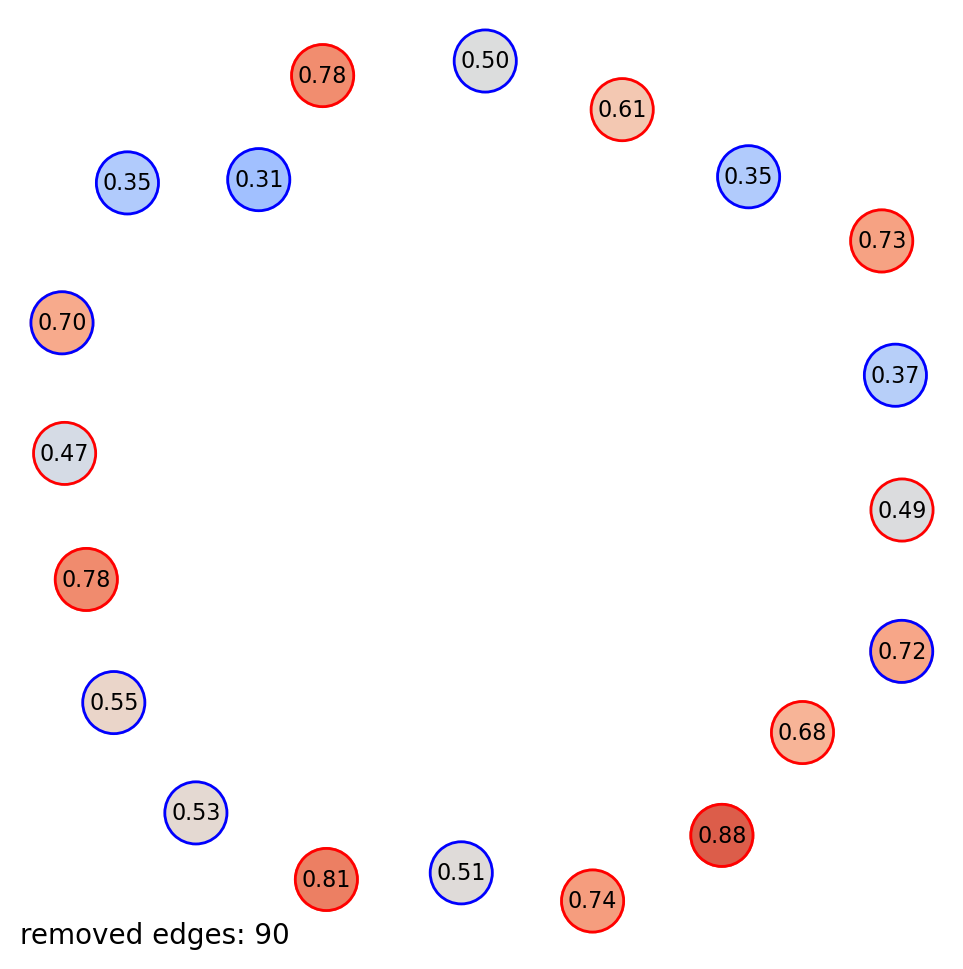

0


In [53]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax = visualize_graph(data=data_list[0], layout="spring", ax=ax)
ax.set_box_aspect(1)
ax.annotate(f"removed edges: {num_edges_to_remove}", xy=(0, 0), xytext=(0, 0), textcoords="axes fraction")
plt.show()

print(data_list[0].num_edges)

## Isolate Nodes

In [132]:
# generate X and y
g1_dist_params = (0.4, 0.2)
g2_dist_params = (0.6, 0.2)
num_nodes_per_class = 10
num_graphs = 100
X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42)

existing_edges = list(combinations(range(0, num_nodes_per_class), 2)) + list(combinations(range(num_nodes_per_class, num_nodes_per_class*2), 2))
existing_nodes = np.arange(0, num_nodes_per_class * 2)
num_existing_nodes = len(existing_nodes)
num_nodes_to_isolate = 20
rng = np.random.default_rng(42)

edges_to_remove = []
nodes_to_isolate = rng.choice(existing_nodes, size=num_nodes_to_isolate, replace=False)
for node_to_isolate in nodes_to_isolate:
    edges_to_remove.extend([(u, v) for u, v in existing_edges if u == node_to_isolate or v == node_to_isolate])
edge_ops = [["remove", src, dst] for src, dst in edges_to_remove]
data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

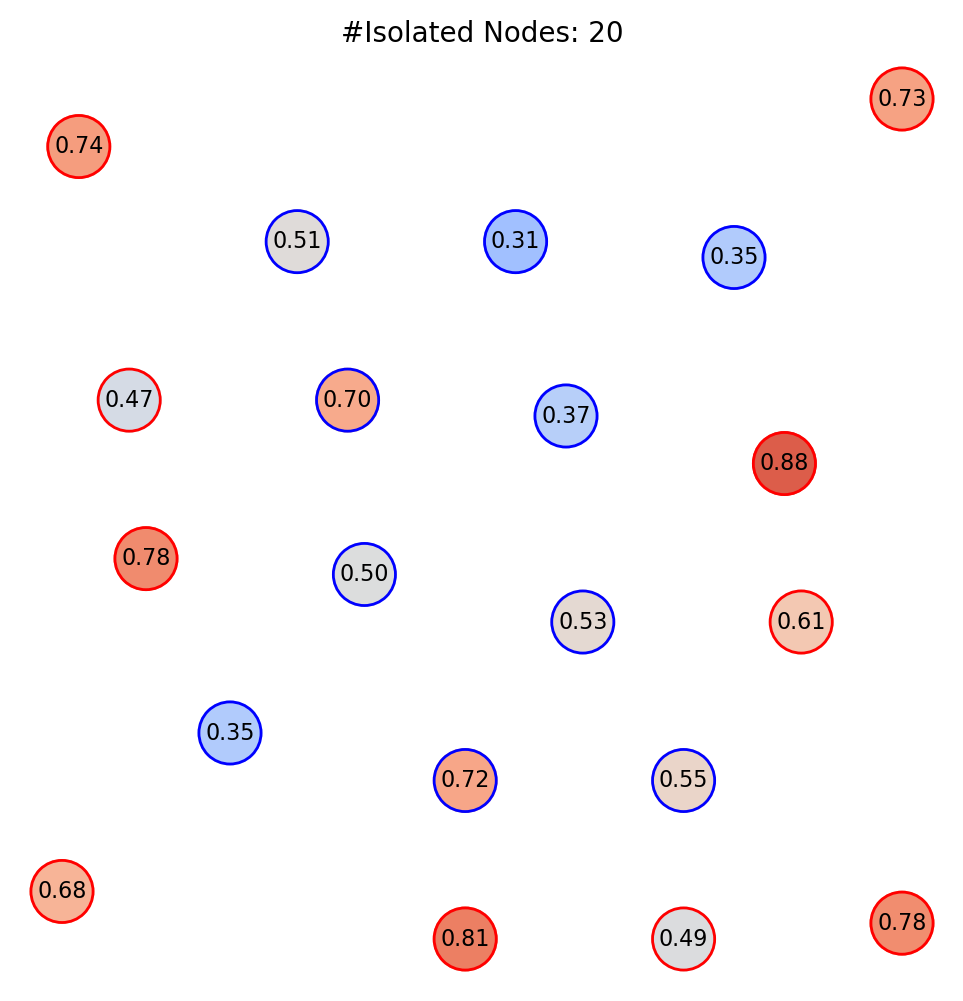

0


In [133]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax = visualize_graph(data=data_list[0], layout="graphviz", ax=ax)
ax.set_box_aspect(1)
# ax.annotate(f"#Isolated Nodes: {num_nodes_to_isolate}", xy=(0, 0), xytext=(0, 0), textcoords="axes fraction")
ax.text(0.5, 1.01, f"#Isolated Nodes: {num_nodes_to_isolate}", transform=ax.transAxes, ha="center", va="bottom")
plt.show()

print(data_list[0].num_edges)

## Detach-and-Rewire

In [21]:
# generate X and y
g1_dist_params = (0.45, 0.1)
g2_dist_params = (0.55, 0.1)
num_nodes_per_class = 10
num_graphs = 100
X, y = generate_data(num_nodes_per_class, g1_dist_params, g2_dist_params, num_graphs, seed=42)

existing_edges = list(combinations(range(0, num_nodes_per_class), 2)) + list(combinations(range(num_nodes_per_class, num_nodes_per_class*2), 2))
existing_nodes = np.arange(0, num_nodes_per_class * 2)
num_existing_nodes = len(existing_nodes)
num_dr = 5
rng = np.random.default_rng(42)

nodes_from_class_0 = existing_nodes[0:num_nodes_per_class]
nodes_from_class_1 = existing_nodes[num_nodes_per_class:num_nodes_per_class*2]
nodes_to_dr = rng.choice(nodes_from_class_0, size=num_dr, replace=False)

edge_ops = []
for node_to_dr in nodes_to_dr:
    edge_ops.extend([["remove", u, v] for u, v in existing_edges if u == node_to_dr or v == node_to_dr])
    edge_ops.extend([["add", node_to_dr, v] for v in nodes_from_class_1])
    # edge_ops.extend([["add", v, node_to_dr] for v in nodes_from_class_1])

# connect detached nodes to other detached nodes
for node in nodes_to_dr:
    for other_node in nodes_to_dr:
        if node != other_node:
            if ["add", node, other_node] not in edge_ops and ["add", other_node, node] not in edge_ops:
                edge_ops.append(["add", node, other_node])

data_list = [make_graph(x, y, edge_ops) for x, y in zip(X, y)]

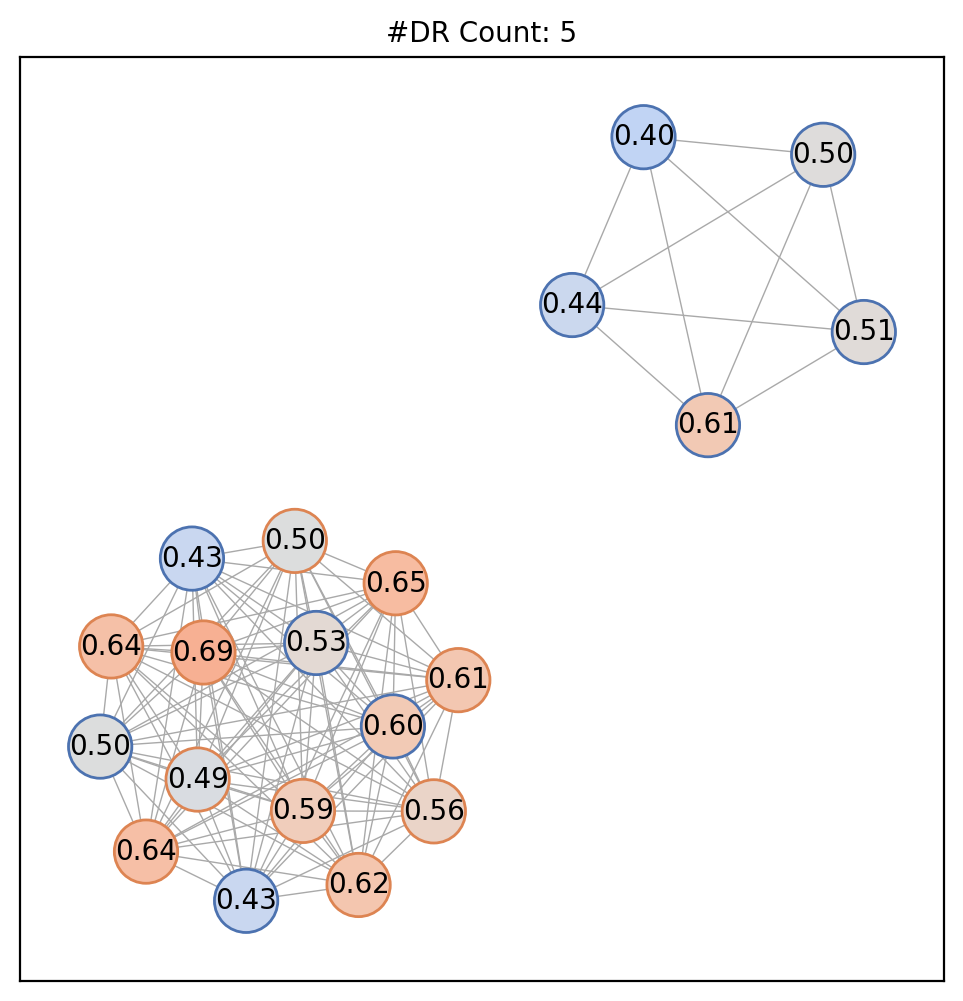

230


In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax = visualize_graph(data=data_list[0], layout="graphviz", ax=ax)
ax.set_box_aspect(1)
ax.text(0.5, 1.01, f"#DR Count: {num_dr}", transform=ax.transAxes, ha="center", va="bottom")
plt.show()

print(data_list[0].num_edges)

# from torch_geometric.utils import to_networkx
# graph = to_networkx(data_list[0], to_undirected=True, node_attrs=["x", "y"])
# nx.adjacency_matrix(graph).todense()